In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("seaborn", sns.__version__)


pandas 2.3.3
numpy 2.3.4
seaborn 0.13.2


In [3]:
import os 

col_names = [
    'engine_id', 'cycle',
    'setting_1', 'setting_2', 'setting_3',
    's1', 's2', 's3', 's4', 's5',
    's6', 's7', 's8', 's9', 's10',
    's11', 's12', 's13', 's14', 's15',
    's16', 's17', 's18', 's19', 's20', 's21'
]

train = pd.read_csv("../data/train_FD001.txt", sep=r'\s+', header=None, names=col_names)
test = pd.read_csv("../data/test_FD001.txt", sep=r'\s+', header=None, names=col_names)
rul = pd.read_csv("../data/RUL_FD001.txt", sep=r'\s+', header=None, names=["RUL"])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"RUL shape: {rul.shape}")

train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,engine_id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print("==INFO TRAIN===")
train.info()

==INFO TRAIN===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   s1         20631 non-null  float64
 6   s2         20631 non-null  float64
 7   s3         20631 non-null  float64
 8   s4         20631 non-null  float64
 9   s5         20631 non-null  float64
 10  s6         20631 non-null  float64
 11  s7         20631 non-null  float64
 12  s8         20631 non-null  float64
 13  s9         20631 non-null  float64
 14  s10        20631 non-null  float64
 15  s11        20631 non-null  float64
 16  s12        20631 non-null  float64
 17  s13        20631 non-null  float64
 18  s14        20631 non-null  float64
 19  s15        20631 non-null  flo

In [9]:
print("=== STATISTIK DASAR ===")

train.describe().round(2)

=== STATISTIK DASAR ===


,engine_id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


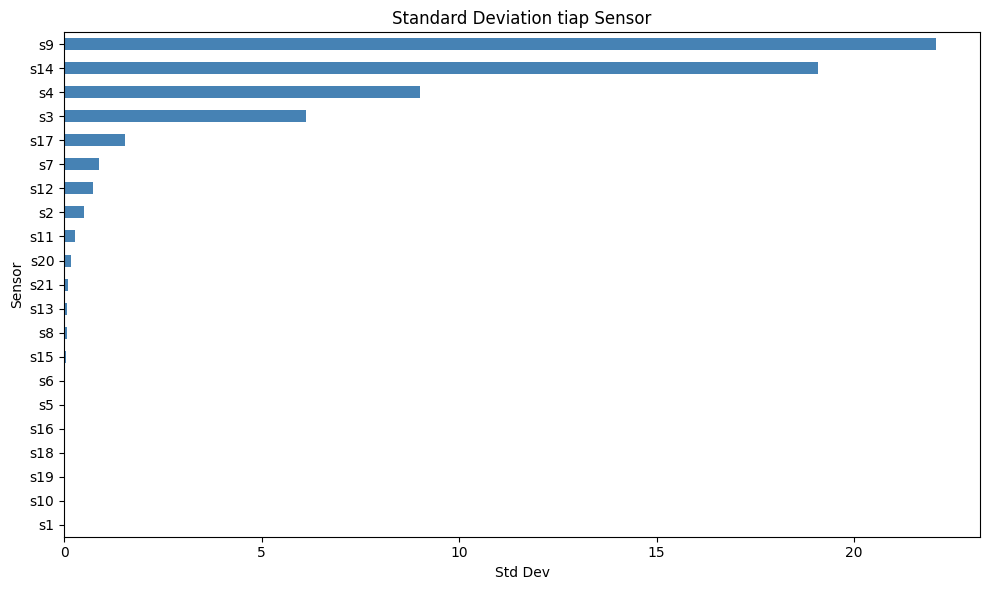

Plot tersimpan di outputs/figures/sensor_std.png


In [5]:
# hitung std tiap sensor
sensor_cols = [f's{i}' for i in range(1, 22)]
std_values = train[sensor_cols].std().sort_values()

# plot
plt.figure(figsize=(10, 6))
std_values.plot(kind='barh', color='steelblue')
plt.title('Standard Deviation tiap Sensor')
plt.xlabel('Std Dev')
plt.ylabel('Sensor')
plt.tight_layout()
plt.savefig('../outputs/sensor_std.png', dpi=150)
plt.show()
print("Plot tersimpan di outputs/figures/sensor_std.png")

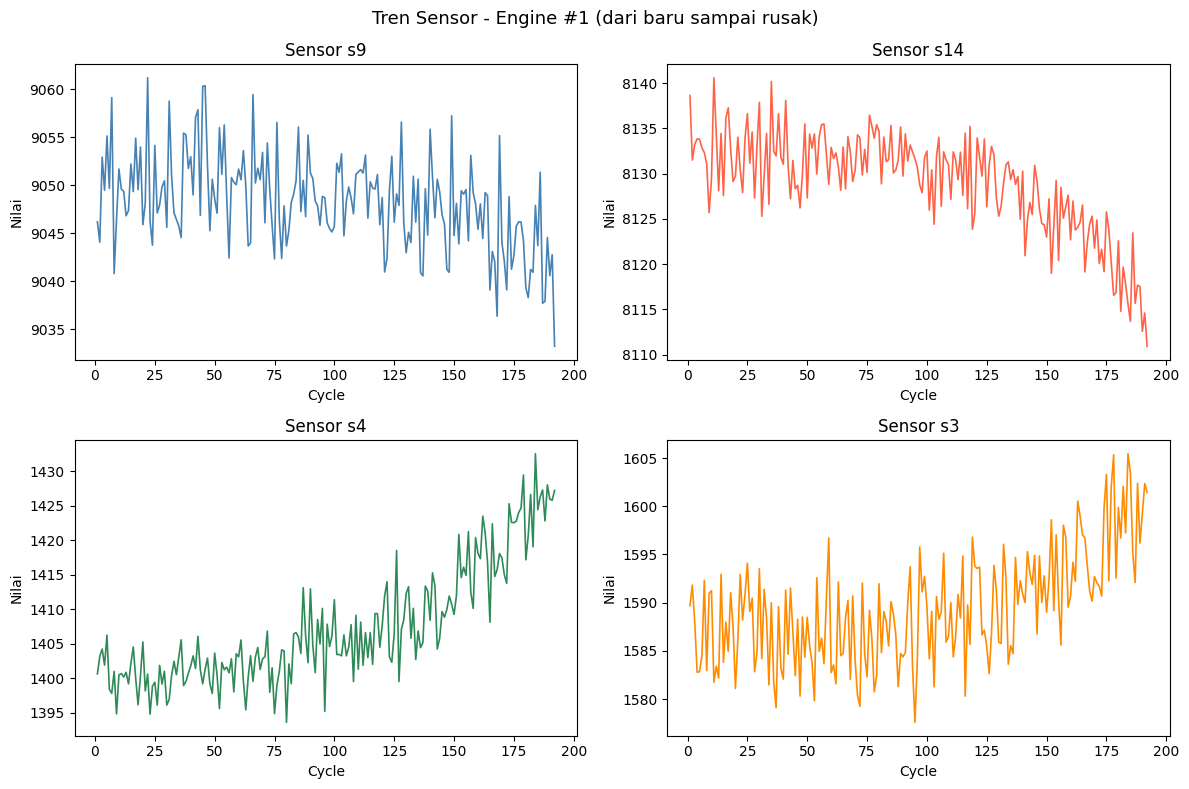

Plot tersimpan!


In [7]:
# ambil data engine_id = 1 saja dulu
engine1 = train[train['engine_id'] == 1]

# plot 4 sensor paling informatif
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Tren Sensor - Engine #1 (dari baru sampai rusak)', fontsize=13)

sensors = ['s9', 's14', 's4', 's3']
colors   = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for ax, sensor, color in zip(axes.flatten(), sensors, colors):
    ax.plot(engine1['cycle'], engine1[sensor], color=color, linewidth=1.2)
    ax.set_title(f'Sensor {sensor}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Nilai')

plt.tight_layout()
plt.savefig('../outputs/sensor_trend_engine1.png', dpi=150)
plt.show()
print("Plot tersimpan!")

In [8]:
# Hitung RUL tiap baris
rul_train = train.groupby("engine_id")['cycle'].max().reset_index()
rul_train.columns = ['engine_id', 'max_cycle']

#merge ke data train
train = train.merge(rul_train, on = 'engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop(columns=['max_cycle'], inplace = True)

print(f"Kolom train sekarang: {train.columns.tolist()}")
print("\nPreview RUL:")
train[['engine_id', 'cycle', 'RUL']].head(10)

Kolom train sekarang: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 'RUL']

Preview RUL:


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


Distribusi label:
Normal (0): 17531 baris (85.0%)
Kritis (1): 3100 baris (15.0%)


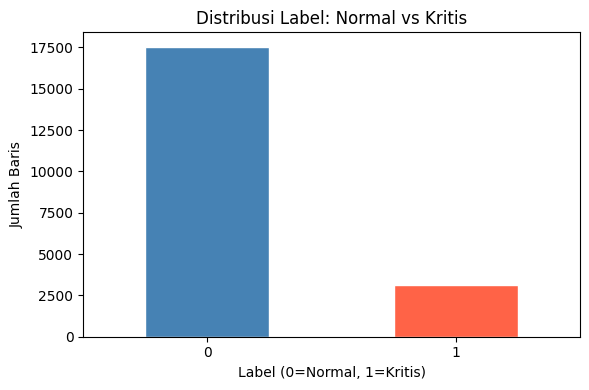

Plot tersimpan!


In [10]:
# buat label binary
# RUL <= 30 = kondisi kritis / anomaly (1)
# RUL > 30  = kondisi normal (0)
# kenapa 30? karena di industri, peringatan dini 30 cycle sebelum rusak
# sudah cukup waktu untuk maintenance

train['label'] = (train['RUL'] <= 30).astype(int)

# cek distribusi label
label_counts = train['label'].value_counts()
print("Distribusi label:")
print(f"Normal (0): {label_counts[0]} baris ({label_counts[0]/len(train)*100:.1f}%)")
print(f"Kritis (1): {label_counts[1]} baris ({label_counts[1]/len(train)*100:.1f}%)")

# visualisasi
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Distribusi Label: Normal vs Kritis')
plt.xlabel('Label (0=Normal, 1=Kritis)')
plt.ylabel('Jumlah Baris')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/label_distribution.png', dpi=150)
plt.show()
print("Plot tersimpan!")